In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

file_path = r"\\cabinet\derivatives\DeepDR\FVs_medsiglip"

data_dict = torch.load(file_path, map_location='cpu', weights_only=False)

print(data_dict)

{'1_l1': array([-0.00104843, -0.04210788, -0.05053651, ...,  0.08659291,
        0.09477806, -0.01597202], shape=(1152,), dtype=float32), '1_l2': array([ 0.006361  , -0.02526498, -0.05128378, ...,  0.13564262,
        0.26890272,  0.03893334], shape=(1152,), dtype=float32), '1_r1': array([-0.18748324,  0.0903331 , -0.00314391, ...,  0.14151713,
        0.02368194,  0.09609091], shape=(1152,), dtype=float32), '1_r2': array([-0.1143087 ,  0.23404425,  0.06412315, ...,  0.11170709,
        0.1274929 ,  0.08837283], shape=(1152,), dtype=float32), '2_l1': array([-0.13801077, -0.06939822,  0.05399406, ..., -0.01206964,
        0.08273798,  0.06057352], shape=(1152,), dtype=float32), '2_l2': array([ 0.06414191, -0.20664507, -0.02594608, ..., -0.07660067,
        0.13670802,  0.14903444], shape=(1152,), dtype=float32), '2_r1': array([-0.12005877, -0.08916503,  0.07291371, ...,  0.00025037,
       -0.05492944,  0.11053789], shape=(1152,), dtype=float32), '2_r2': array([-0.05514766,  0.06435275,

In [2]:
keys = sorted(data_dict.keys(), key=lambda k: (int(k.split('_')[0]), k.split('_')[1]))

X = np.stack([
    data_dict[k].numpy() if isinstance(data_dict[k], torch.Tensor) else np.array(data_dict[k])
    for k in keys
], axis=0)

print("X shape:", X.shape)
print("X dtype:", X.dtype)


X shape: (1200, 1152)
X dtype: float32


In [3]:
import numpy as np

print("X shape:", X.shape)
print("X dtype:", X.dtype)
print("NaN:", np.isnan(X).any())
print("Inf:", np.isinf(X).any())
print("MIN:", X.min())
print("MAX:", X.max())
print("MEAN:", X.mean())
print("STD:", X.std())

X shape: (1200, 1152)
X dtype: float32
NaN: False
Inf: False
MIN: -0.9001107
MAX: 0.91445804
MEAN: 0.0008397813
STD: 0.15229274


In [4]:
np.savez_compressed("deepdr_pca_input.npz", X=X, keys=np.array(keys, dtype=object))

In [5]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X)

print("X_pca shape:", X_pca.shape)
print("Explained Variance of first 10:")
print(pca.explained_variance_ratio_[:10])

print("Cumulative Explained Variance of first 10:")
print(np.cumsum(pca.explained_variance_ratio_)[:10])

X_pca shape: (1200, 1152)
Explained Variance of first 10:
[0.21312194 0.13846846 0.09466582 0.07602319 0.0457683  0.03345345
 0.03220747 0.02619656 0.0230416  0.01935018]
Cumulative Explained Variance of first 10:
[0.21312194 0.3515904  0.44625622 0.5222794  0.5680477  0.60150117
 0.63370866 0.6599052  0.6829468  0.702297  ]


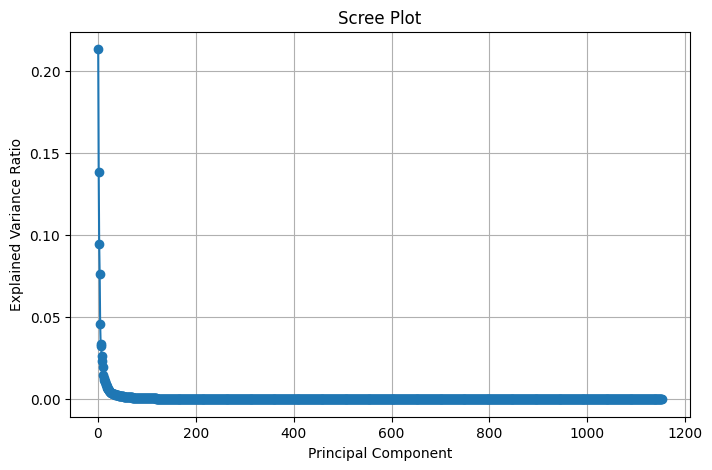

In [6]:
import matplotlib.pyplot as plt

explained = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained) + 1), explained, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)
plt.show()

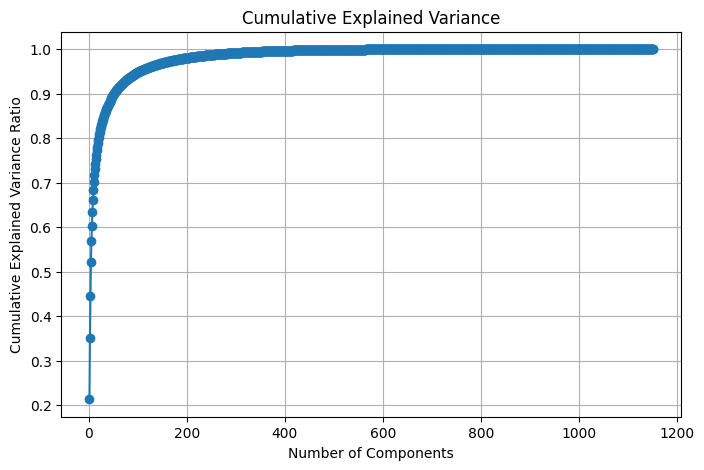

In [7]:
cum_explained = np.cumsum(explained)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_explained) + 1), cum_explained, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [10]:
k80 = np.argmax(cum_explained >= 0.80) + 1
k90 = np.argmax(cum_explained >= 0.90) + 1
k95 = np.argmax(cum_explained >= 0.95) + 1

print(f"80%:{k80}\n90%:{k90}\n95%:{k95}")

80%:20
90%:52
95%:103


In [12]:
import numpy as np

keys = sorted(
    data_dict.keys(), 
    key=lambda k: (int(k.split('_')[0]), k.split('_')[1]))

patient_ids = []
eyes = []
views = []

for k in keys:
    pid, suffix = k.split("_")
    eye = suffix[0]      # l / r
    view = suffix[1]     # 1 / 2

    patient_ids.append(int(pid))
    eyes.append(eye)
    views.append(int(view))

patient_ids = np.array(patient_ids)
eyes = np.array(eyes)
views = np.array(views)

print(patient_ids[:10])
print(eyes[:10])
print(views[:10])

[1 1 1 1 2 2 2 2 3 3]
['l' 'l' 'r' 'r' 'l' 'l' 'r' 'r' 'l' 'l']
[1 2 1 2 1 2 1 2 1 2]


In [13]:
for i in range(10):
    pc = X_pca[:, i]
    mean_l = pc[eyes == 'l'].mean()
    mean_r = pc[eyes == 'r'].mean()
    print(f"PC{i+1}: mean_l={mean_l:.4f}, mean_r={mean_r:.4f}, diff={mean_r - mean_l:.4f}")

PC1: mean_l=0.0422, mean_r=-0.0421, diff=-0.0843
PC2: mean_l=1.2152, mean_r=-1.2111, diff=-2.4263
PC3: mean_l=-0.0379, mean_r=0.0377, diff=0.0756
PC4: mean_l=-0.0411, mean_r=0.0410, diff=0.0821
PC5: mean_l=0.0312, mean_r=-0.0311, diff=-0.0624
PC6: mean_l=0.0092, mean_r=-0.0092, diff=-0.0184
PC7: mean_l=0.0125, mean_r=-0.0124, diff=-0.0249
PC8: mean_l=0.0020, mean_r=-0.0020, diff=-0.0040
PC9: mean_l=0.0260, mean_r=-0.0259, diff=-0.0519
PC10: mean_l=-0.0067, mean_r=0.0067, diff=0.0133


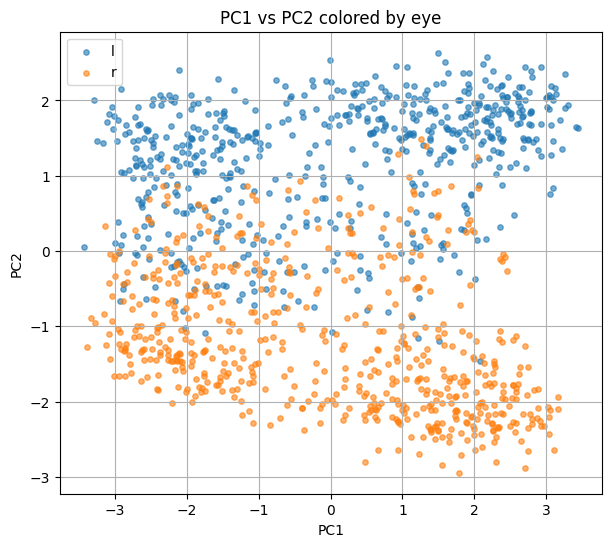

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
for e in ['l', 'r']:
    mask = eyes == e
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=15, alpha=0.6, label=e)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2 colored by eye")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
for i in range(10):
    pc = X_pca[:, i]
    mean_v1 = pc[views == 1].mean()
    mean_v2 = pc[views == 2].mean()
    print(f"PC{i+1}: mean_v1={mean_v1:.4f}, mean_v2={mean_v2:.4f}, diff={mean_v2 - mean_v1:.4f}")

PC1: mean_v1=-0.0552, mean_v2=0.0208, diff=0.0759
PC2: mean_v1=0.0355, mean_v2=-0.0488, diff=-0.0843
PC3: mean_v1=-0.1827, mean_v2=0.1758, diff=0.3585
PC4: mean_v1=-0.1434, mean_v2=0.1415, diff=0.2849
PC5: mean_v1=-0.4469, mean_v2=0.4467, diff=0.8936
PC6: mean_v1=-0.2168, mean_v2=0.2179, diff=0.4347
PC7: mean_v1=0.1802, mean_v2=-0.1704, diff=-0.3506
PC8: mean_v1=-0.1358, mean_v2=0.1322, diff=0.2680
PC9: mean_v1=-0.0084, mean_v2=0.0037, diff=0.0121
PC10: mean_v1=-0.0525, mean_v2=0.0609, diff=0.1134


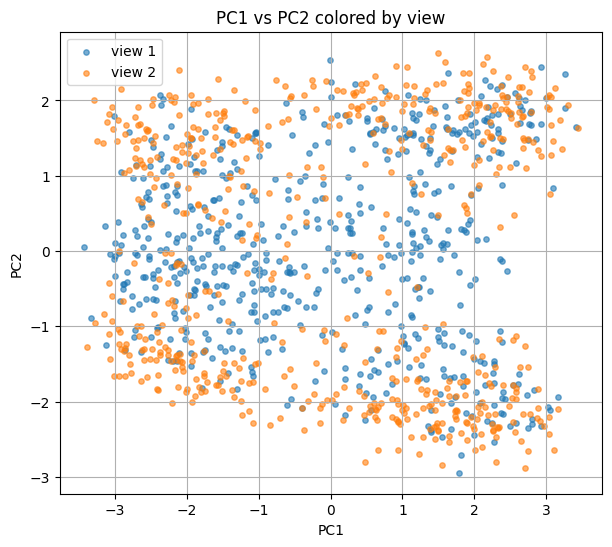

In [16]:
plt.figure(figsize=(7,6))
for v in [1, 2]:
    mask = views == v
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=15, alpha=0.6, label=f"view {v}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2 colored by view")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
from scipy.stats import ttest_ind
import numpy as np

for i in range(10):
    pc = X_pca[:, i]
    l_vals = pc[eyes == 'l']
    r_vals = pc[eyes == 'r']

    t_stat, p_val = ttest_ind(l_vals, r_vals, equal_var=False)

    # Cohen's d
    mean_diff = l_vals.mean() - r_vals.mean()
    pooled_std = np.sqrt((l_vals.std(ddof=1)**2 + r_vals.std(ddof=1)**2) / 2)
    cohen_d = mean_diff / pooled_std

    print(f"PC{i+1}: p={p_val:.3e}, Cohen's d={cohen_d:.4f}")

PC1: p=4.323e-01, Cohen's d=0.0454
PC2: p=0.000e+00, Cohen's d=2.7584
PC3: p=2.909e-01, Cohen's d=-0.0610
PC4: p=2.007e-01, Cohen's d=-0.0739
PC5: p=2.099e-01, Cohen's d=0.0724
PC6: p=6.648e-01, Cohen's d=0.0250
PC7: p=5.512e-01, Cohen's d=0.0344
PC8: p=9.157e-01, Cohen's d=0.0061
PC9: p=1.412e-01, Cohen's d=0.0850
PC10: p=6.804e-01, Cohen's d=-0.0238


In [18]:
for i in range(10):
    pc = X_pca[:, i]
    v1_vals = pc[views == 1]
    v2_vals = pc[views == 2]

    t_stat, p_val = ttest_ind(v1_vals, v2_vals, equal_var=False)

    mean_diff = v1_vals.mean() - v2_vals.mean()
    pooled_std = np.sqrt((v1_vals.std(ddof=1)**2 + v2_vals.std(ddof=1)**2) / 2)
    cohen_d = mean_diff / pooled_std

    print(f"PC{i+1}: p={p_val:.3e}, Cohen's d={cohen_d:.4f}")

PC1: p=4.807e-01, Cohen's d=-0.0409
PC2: p=3.327e-01, Cohen's d=0.0562
PC3: p=5.651e-07, Cohen's d=-0.2918
PC4: p=9.776e-06, Cohen's d=-0.2576
PC5: p=0.000e+00, Cohen's d=-1.2119
PC6: p=2.737e-25, Cohen's d=-0.6168
PC7: p=1.723e-17, Cohen's d=0.5014
PC8: p=8.850e-13, Cohen's d=-0.4192
PC9: p=7.331e-01, Cohen's d=-0.0198
PC10: p=4.400e-04, Cohen's d=-0.2044


In [19]:
from collections import defaultdict, Counter

# data_dict: 例如 {"1_l1": ..., "1_l2": ..., "1_r1": ..., ...}

eye_count = defaultdict(lambda: {"l": 0, "r": 0})
view_detail = defaultdict(list)

for k in data_dict.keys():
    # 例如 k = "12_l1"
    parts = k.split("_")
    if len(parts) != 2:
        print(f"格式异常: {k}")
        continue

    pid, eyeview = parts
    eye = eyeview[0]   # l 或 r
    view = eyeview[1:] # 1 或 2

    if eye in ["l", "r"]:
        eye_count[pid][eye] += 1
        view_detail[pid].append(eyeview)
    else:
        print(f"未知眼别: {k}")

# 1. 全局左右眼总数
total_left = sum(v["l"] for v in eye_count.values())
total_right = sum(v["r"] for v in eye_count.values())

print("全局统计：")
print(f"左眼总数 = {total_left}")
print(f"右眼总数 = {total_right}")
print(f"左右眼总数是否相等: {total_left == total_right}")

# 2. 每个编号是否左右一对一
not_one_to_one = []
for pid, cnt in eye_count.items():
    if cnt["l"] != cnt["r"]:
        not_one_to_one.append((pid, cnt["l"], cnt["r"], sorted(view_detail[pid])))

print("\n每个编号左右是否一对一：")
print(f"总编号数 = {len(eye_count)}")
print(f"左右数量不相等的编号数 = {len(not_one_to_one)}")

# 显示前20个异常编号
for item in not_one_to_one[:20]:
    pid, lcnt, rcnt, views = item
    print(f"id={pid}, left={lcnt}, right={rcnt}, views={views}")

# 3. 看看常见模式
pattern_counter = Counter()
for pid, views in view_detail.items():
    pattern_counter[tuple(sorted(views))] += 1

print("\n最常见的视角组合模式（前10个）：")
for pattern, cnt in pattern_counter.most_common(10):
    print(pattern, cnt)

全局统计：
左眼总数 = 599
右眼总数 = 601
左右眼总数是否相等: False

每个编号左右是否一对一：
总编号数 = 300
左右数量不相等的编号数 = 1
id=164, left=1, right=3, views=['l3', 'r1', 'r3', 'r4']

最常见的视角组合模式（前10个）：
('l1', 'l2', 'r1', 'r2') 296
('l1', 'l3', 'r2', 'r3') 1
('l3', 'l4', 'r3', 'r4') 1
('l3', 'r1', 'r3', 'r4') 1
('l2', 'l3', 'r2', 'r3') 1


In [20]:
from collections import defaultdict, Counter

# 1. 按编号收集后缀
id_to_suffixes = defaultdict(list)
for k in data_dict.keys():
    pid, suffix = k.split("_", 1)
    id_to_suffixes[pid].append(suffix)

# 2. 定义标准模式
expected = ['l1', 'l2', 'r1', 'r2']

# 3. 找出异常编号
bad_ids = {}
for pid, suffixes in id_to_suffixes.items():
    suffixes_sorted = sorted(suffixes)
    if suffixes_sorted != expected:
        bad_ids[pid] = suffixes_sorted

print("总编号数:", len(id_to_suffixes))
print("异常编号数:", len(bad_ids))
print()

# 4. 逐个打印异常编号
print("=== 异常编号详情 ===")
for pid in sorted(bad_ids, key=lambda x: int(x)):
    raw_keys = sorted([k for k in data_dict.keys() if k.startswith(f"{pid}_")])
    print(f"id={pid}")
    print(f"  suffixes = {bad_ids[pid]}")
    print(f"  raw_keys  = {raw_keys}")
    print()

# 5. 统计异常模式出现次数
pattern_counter = Counter(tuple(v) for v in bad_ids.values())

print("=== 异常模式统计 ===")
for pattern, cnt in pattern_counter.most_common():
    print(f"{pattern} : {cnt}")

总编号数: 300
异常编号数: 4

=== 异常编号详情 ===
id=56
  suffixes = ['l1', 'l3', 'r2', 'r3']
  raw_keys  = ['56_l1', '56_l3', '56_r2', '56_r3']

id=77
  suffixes = ['l3', 'l4', 'r3', 'r4']
  raw_keys  = ['77_l3', '77_l4', '77_r3', '77_r4']

id=164
  suffixes = ['l3', 'r1', 'r3', 'r4']
  raw_keys  = ['164_l3', '164_r1', '164_r3', '164_r4']

id=167
  suffixes = ['l2', 'l3', 'r2', 'r3']
  raw_keys  = ['167_l2', '167_l3', '167_r2', '167_r3']

=== 异常模式统计 ===
('l1', 'l3', 'r2', 'r3') : 1
('l3', 'l4', 'r3', 'r4') : 1
('l3', 'r1', 'r3', 'r4') : 1
('l2', 'l3', 'r2', 'r3') : 1


## PCA with cleaned data